# EXPT NO: 3 — IMPLEMENTATION OF CONVOLUTIONAL NEURAL NETWORKS (CNNs) FOR IMAGE CLASSIFICATION

**Name:** Abhishek J  
**Roll No:** 24BAD002  


---



## DATASET
**Fashion-MNIST** is used as the benchmark dataset. It contains 70,000 28x28 grayscale images across 10 clothing categories (T-shirt/top, Trouser, Pullover, Dress, Coat, Sandal, Shirt, Sneaker, Bag, Ankle boot) — 60,000 for training and 10,000 for testing. It is directly available via `tf.keras.datasets.fashion_mnist`, requires no manual Kaggle download, is small and fast to load/train, and is a widely used benchmark specifically designed to be a harder, more realistic drop-in replacement for MNIST when evaluating CNNs.



## PART A: DATASET PREPARATION

In [1]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

print("TensorFlow version:", tf.__version__)
print("24BAD002_ABHISHEK J")


TensorFlow version: 2.20.0
24BAD002_ABHISHEK J


In [2]:
# Load Fashion-MNIST dataset (benchmark dataset, built into Keras)
(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print("Full training set shape:", x_train_full.shape, y_train_full.shape)
print("Test set shape:", x_test.shape, y_test.shape)


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Full training set shape: (60000, 28, 28) (60000,)
Test set shape: (10000, 28, 28) (10000,)


In [3]:
# Preprocess: normalize pixel values to [0, 1] and add channel dimension
x_train_full = x_train_full.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Fashion-MNIST images are grayscale (H, W) -> reshape to (H, W, 1) for Conv2D
x_train_full = x_train_full[..., np.newaxis]
x_test = x_test[..., np.newaxis]

y_train_full = y_train_full.flatten()
y_test = y_test.flatten()

# Split training set into training and validation sets (90/10 split)
val_size = int(0.1 * len(x_train_full))
x_val, y_val = x_train_full[:val_size], y_train_full[:val_size]
x_train, y_train = x_train_full[val_size:], y_train_full[val_size:]

print("Training set:", x_train.shape, y_train.shape)
print("Validation set:", x_val.shape, y_val.shape)
print("Test set:", x_test.shape, y_test.shape)


Training set: (54000, 28, 28, 1) (54000,)
Validation set: (6000, 28, 28, 1) (6000,)
Test set: (10000, 28, 28, 1) (10000,)


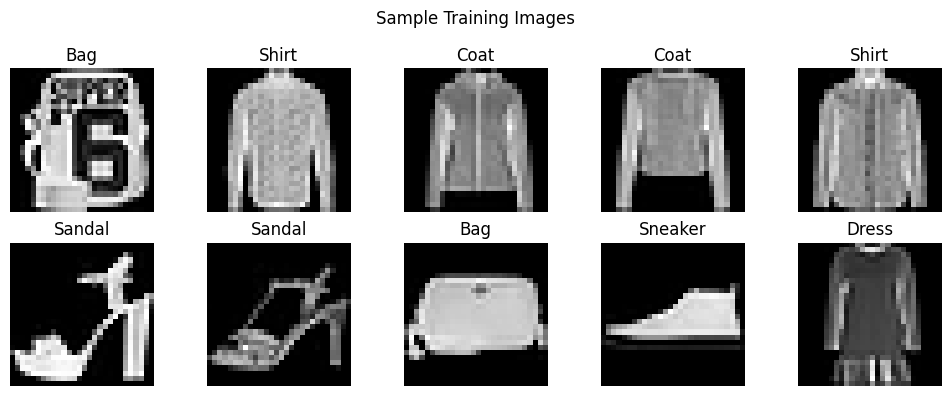

In [4]:
# Visualize a few sample images from the training set
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].squeeze(), cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.suptitle("Sample Training Images")
plt.tight_layout()
plt.show()


## PART B: CNN MODEL IMPLEMENTATION

In [5]:
# Build the CNN model
model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')   # Softmax output layer
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Compile the model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',   # cross-entropy loss
    metrics=['accuracy']
)


## PART C: MODEL TRAINING AND EVALUATION

In [7]:
# Train the CNN model
callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
]

history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=15,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.7835 - loss: 0.6009 - val_accuracy: 0.8642 - val_loss: 0.3674
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8535 - loss: 0.4053 - val_accuracy: 0.8885 - val_loss: 0.3008
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8696 - loss: 0.3566 - val_accuracy: 0.8948 - val_loss: 0.2849
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8809 - loss: 0.3272 - val_accuracy: 0.9022 - val_loss: 0.2576
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8881 - loss: 0.3060 - val_accuracy: 0.9098 - val_loss: 0.2473
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8946 - loss: 0.2891 - val_accuracy: 0.9138 - val_loss: 0.2382
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8986 - loss: 0.2761 - val_accuracy: 0.9125 - val_loss: 0.2303
Epoch 8/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9027 - loss: 0.2640 - val_accuracy: 

In [8]:
# Record final training/validation metrics
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]
train_loss = history.history['loss'][-1]
val_loss = history.history['val_loss'][-1]

print(f"Final Training Accuracy   : {train_acc:.4f}")
print(f"Final Validation Accuracy : {val_acc:.4f}")
print(f"Final Training Loss       : {train_loss:.4f}")
print(f"Final Validation Loss     : {val_loss:.4f}")


Final Training Accuracy   : 0.9177
Final Validation Accuracy : 0.9252
Final Training Loss       : 0.2178
Final Validation Loss     : 0.1973


In [9]:
# Evaluate on the test set
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Testing Accuracy : {test_acc:.4f}")
print(f"Testing Loss     : {test_loss:.4f}")


Testing Accuracy : 0.9185
Testing Loss     : 0.2209


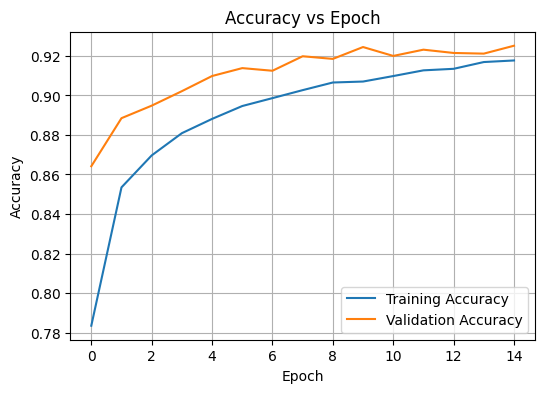

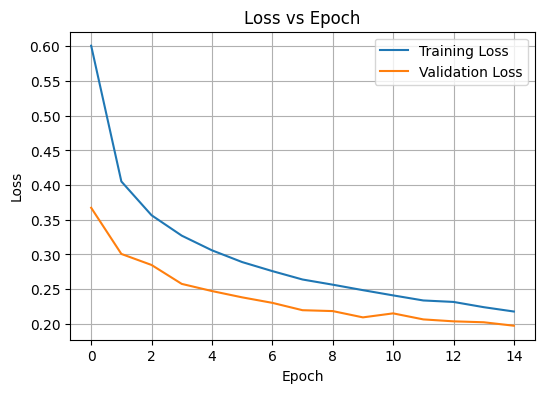

In [10]:
# Plot Accuracy vs Epoch
plt.figure(figsize=(6, 4))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Plot Loss vs Epoch
plt.figure(figsize=(6, 4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


## PART D: PERFORMANCE ANALYSIS

In [11]:
# Predictions on the test set
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Classification accuracy
print("Overall Test Classification Accuracy:", (y_pred == y_test).mean())
print()
print(classification_report(y_test, y_pred, target_names=class_names))


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Overall Test Classification Accuracy: 0.9185

              precision    recall  f1-score   support

 T-shirt/top       0.86      0.89      0.87      1000
     Trouser       0.99      0.98      0.99      1000
    Pullover       0.86      0.89      0.88      1000
       Dress       0.92      0.93      0.92      1000
        Coat       0.86      0.87      0.87      1000
      Sandal       0.99      0.97      0.98      1000
       Shirt       0.79      0.72      0.75      1000
     Sneaker       0.94      0.99      0.96      1000
         Bag       0.99      0.98      0.99      1000
  Ankle boot       0.98      0.96      0.97      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



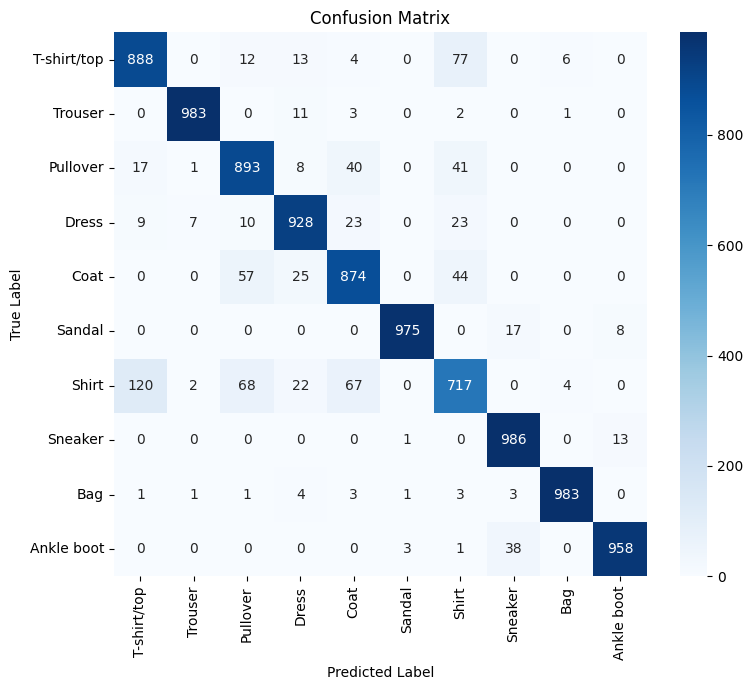

In [12]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()


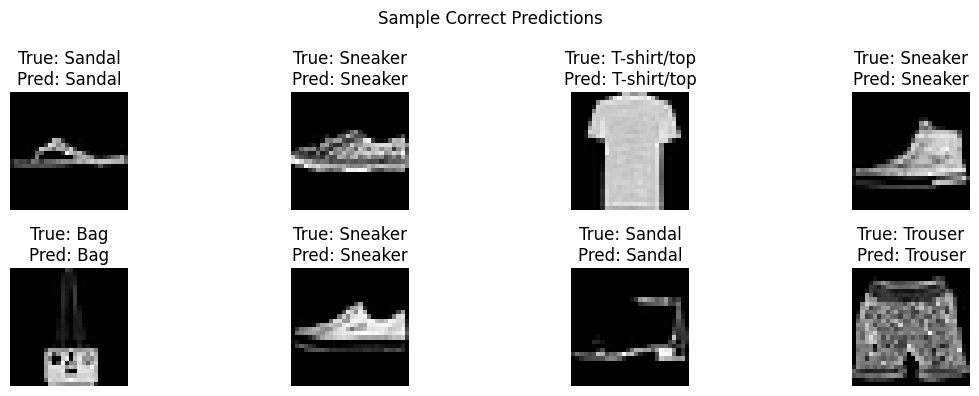

In [13]:
# Sample correct predictions
correct_idx = np.where(y_pred == y_test)[0]
sample_correct = np.random.choice(correct_idx, 8, replace=False)

plt.figure(figsize=(12, 4))
for i, idx in enumerate(sample_correct):
    plt.subplot(2, 4, i + 1)
    plt.imshow(x_test[idx].squeeze(), cmap='gray')
    plt.title(f"True: {class_names[y_test[idx]]}\nPred: {class_names[y_pred[idx]]}")
    plt.axis('off')
plt.suptitle("Sample Correct Predictions")
plt.tight_layout()
plt.show()


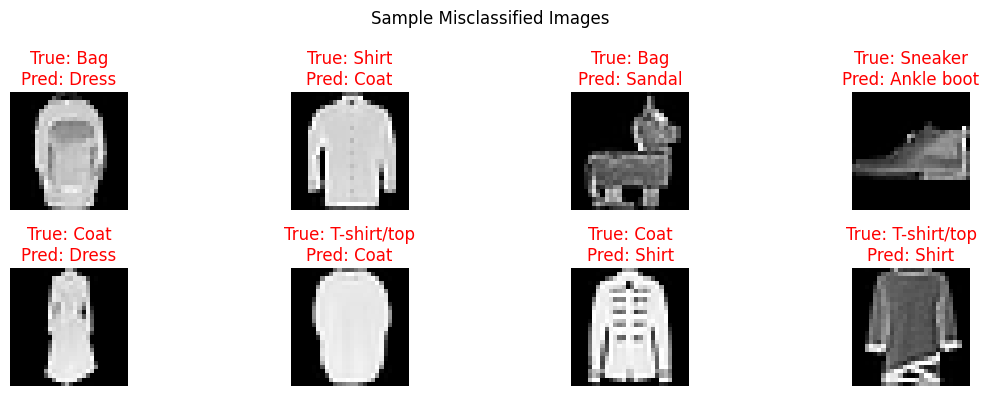

Total misclassified images: 815 out of 10000


In [14]:
# Misclassified images
misclassified_idx = np.where(y_pred != y_test)[0]
sample_wrong = np.random.choice(misclassified_idx, 8, replace=False)

plt.figure(figsize=(12, 4))
for i, idx in enumerate(sample_wrong):
    plt.subplot(2, 4, i + 1)
    plt.imshow(x_test[idx].squeeze(), cmap='gray')
    plt.title(f"True: {class_names[y_test[idx]]}\nPred: {class_names[y_pred[idx]]}", color='red')
    plt.axis('off')
plt.suptitle("Sample Misclassified Images")
plt.tight_layout()
plt.show()

print(f"Total misclassified images: {len(misclassified_idx)} out of {len(y_test)}")


### Strengths and Limitations of CNNs for Image Classification

**Strengths:**
- Automatically learn hierarchical spatial features without manual feature engineering.
- Parameter sharing (via convolution) makes CNNs efficient compared to fully connected networks on images.
- Translation invariance from pooling layers helps recognize objects regardless of position.
- Scale well to large, high-resolution image datasets when combined with GPUs.

**Limitations:**
- Require large amounts of labeled data and significant computational resources to train well.
- Can struggle with rotation, scale, or heavy occlusion unless augmentation/specialized architectures are used.
- Prone to overfitting on small datasets without regularization (dropout, augmentation, weight decay).
- Act as "black boxes" — decisions are difficult to interpret without additional explainability techniques.
